# Report Figures for MATH 629 Project

This notebook creates clean visualizations for the report using the saved metrics already shown in `main.ipynb`.

It does **not** retrain any model or change any experiment setting. It only visualizes the final reported results.

Generated figures are saved to `report_figures/` so they can be inserted into the LaTeX report.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['savefig.dpi'] = 300

FIG_DIR = Path('report_figures')
FIG_DIR.mkdir(exist_ok=True)

regression_df = pd.DataFrame([
    {
        'Model': 'DeepLOB',
        'Return MAE (bps)': 1.610279,
        'Return RMSE (bps)': 2.791448,
        'Return IC': 0.163038,
        'Direction Accuracy': 0.535740,
        'RMSE Gain vs Persistence (bps)': 0.037349,
    },
    {
        'Model': 'Transformer',
        'Return MAE (bps)': 1.620080,
        'Return RMSE (bps)': 2.803324,
        'Return IC': 0.140686,
        'Direction Accuracy': 0.539676,
        'RMSE Gain vs Persistence (bps)': 0.025474,
    },
    {
        'Model': 'Hybrid',
        'Return MAE (bps)': 1.612281,
        'Return RMSE (bps)': 2.790846,
        'Return IC': 0.165116,
        'Direction Accuracy': 0.537585,
        'RMSE Gain vs Persistence (bps)': 0.037951,
    },
])

persistence_rmse = 2.828798

classification_df = pd.DataFrame([
    {
        'Setup': 'Flat Baseline (Naive)',
        'Accuracy': 0.156024,
        'Balanced Accuracy': 0.333333,
        'Macro F1': 0.089977,
        'Non-flat Precision': np.nan,
        'Non-flat Recall': 0.0,
        'Predicted Non-flat Share': 0.0,
        'Actual Non-flat Share': 0.843976,
    },
    {
        'Setup': 'Naive Model',
        'Accuracy': 0.550027,
        'Balanced Accuracy': 0.479533,
        'Macro F1': 0.486062,
        'Non-flat Precision': 0.557307,
        'Non-flat Recall': 0.612216,
        'Predicted Non-flat Share': 0.927129,
        'Actual Non-flat Share': 0.843976,
    },
    {
        'Setup': 'Flat Baseline (Improved)',
        'Accuracy': 0.192740,
        'Balanced Accuracy': 0.333333,
        'Macro F1': 0.107730,
        'Non-flat Precision': np.nan,
        'Non-flat Recall': 0.0,
        'Predicted Non-flat Share': 0.0,
        'Actual Non-flat Share': 0.807260,
    },
    {
        'Setup': 'Improved Model',
        'Accuracy': 0.553481,
        'Balanced Accuracy': 0.507444,
        'Macro F1': 0.512183,
        'Non-flat Precision': 0.565680,
        'Non-flat Recall': 0.616395,
        'Predicted Non-flat Share': 0.879634,
        'Actual Non-flat Share': 0.807260,
    },
])

train_class_distribution = pd.DataFrame({
    'Class': ['Down', 'Flat', 'Up'],
    'Naive Labels': [0.393264, 0.211058, 0.395679],
    'Improved Labels': [0.375491, 0.244077, 0.380432],
})

naive_confusion = np.array([
    [48475,  3723, 28511],
    [11699,  6234, 11248],
    [25305,  3672, 48162],
])

improved_confusion = np.array([
    [48275,  6054, 22615],
    [13389, 10453, 12206],
    [23243,  6005, 44789],
])

split_df = pd.DataFrame([
    {'Split': 'Train', 'Rows': 561102, 'Sequences': 561093},
    {'Split': 'Validation', 'Rows': 187028, 'Sequences': 187019},
    {'Split': 'Test', 'Rows': 187038, 'Sequences': 187029},
])

dataset_overview = pd.Series({
    'Raw rows': 3730870,
    'Cleaned 1s rows': 935198,
    'Avg raw rows/sec': 3.989390482015573,
})

regression_df


,Model,Return MAE (bps),Return RMSE (bps),Return IC,Direction Accuracy,RMSE Gain vs Persistence (bps)
0,DeepLOB,1.610279,2.791448,0.163038,0.535740,0.037349
1,Transformer,1.620080,2.803324,0.140686,0.539676,0.025474
2,Hybrid,1.612281,2.790846,0.165116,0.537585,0.037951


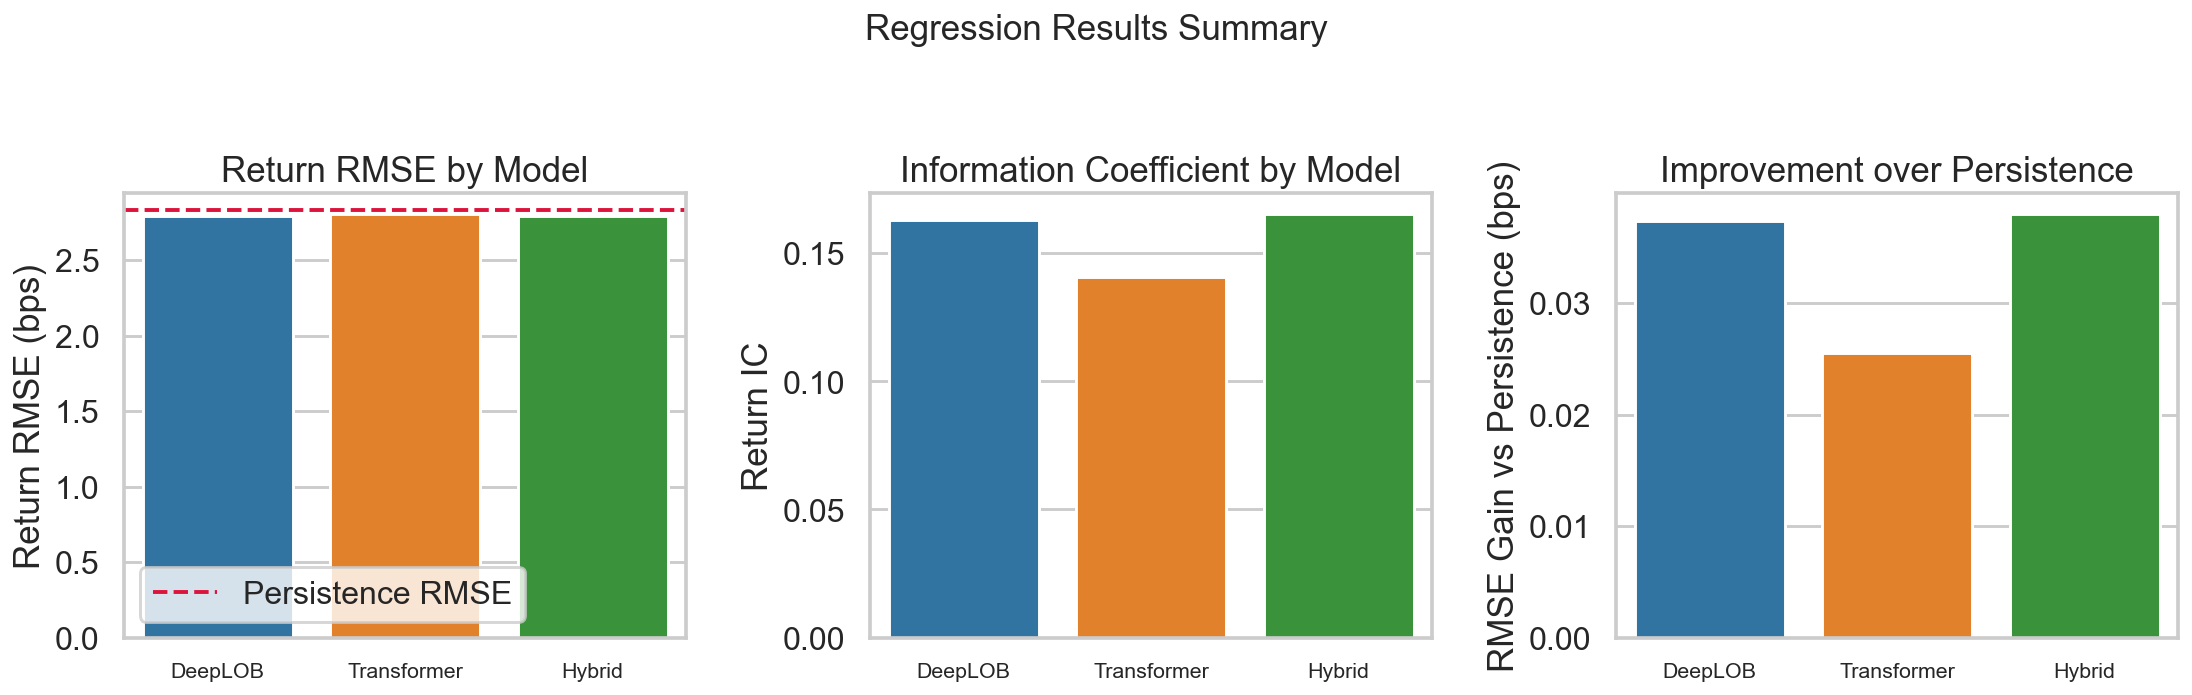

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
palette = ['#1f77b4', '#ff7f0e', '#2ca02c']

sns.barplot(data=regression_df, x='Model', y='Return RMSE (bps)', hue='Model', dodge=False, legend=False, ax=axes[0], palette=palette)
axes[0].axhline(persistence_rmse, color='crimson', linestyle='--', linewidth=2, label='Persistence RMSE')
axes[0].set_title('Return RMSE by Model')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0, labelsize=11)
axes[0].legend(frameon=True)

sns.barplot(data=regression_df, x='Model', y='Return IC', hue='Model', dodge=False, legend=False, ax=axes[1], palette=palette)
axes[1].set_title('Information Coefficient by Model')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0, labelsize=11)

sns.barplot(data=regression_df, x='Model', y='RMSE Gain vs Persistence (bps)', hue='Model', dodge=False, legend=False, ax=axes[2], palette=palette)
axes[2].set_title('Improvement over Persistence')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0, labelsize=11)

fig.suptitle('Regression Results Summary', fontsize=18, y=1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / 'regression_results_summary.png', bbox_inches='tight')
plt.show()


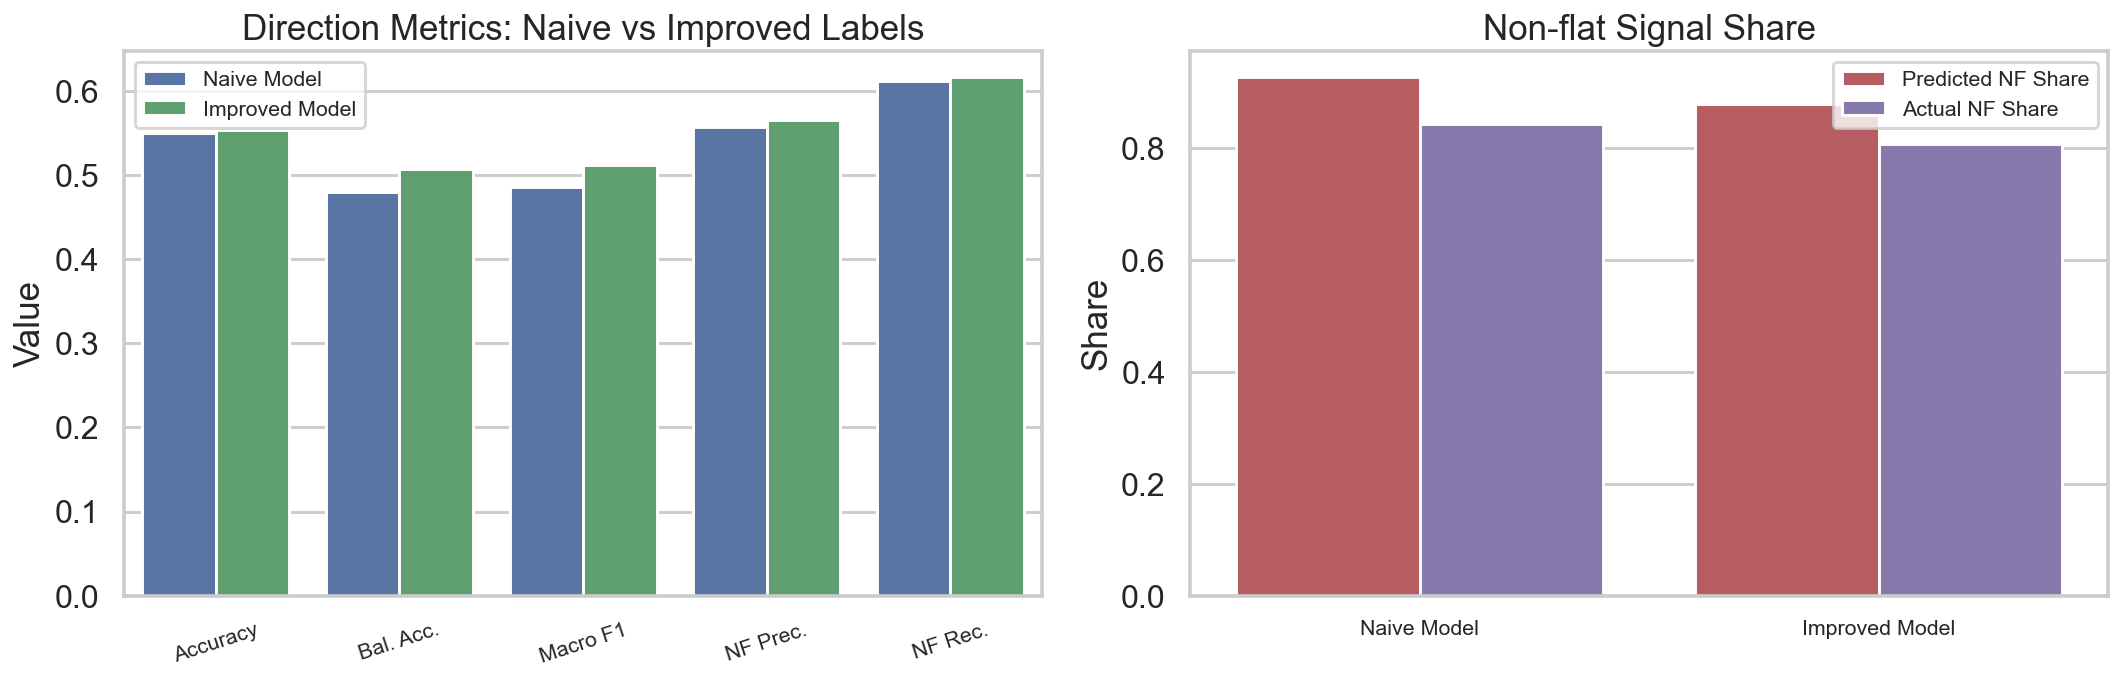

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))

comparison_subset = classification_df[classification_df['Setup'].isin(['Naive Model', 'Improved Model'])].copy()
metrics_long = comparison_subset.melt(
    id_vars='Setup',
    value_vars=['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Non-flat Precision', 'Non-flat Recall'],
    var_name='Metric',
    value_name='Value'
)
metrics_long['Metric'] = metrics_long['Metric'].replace({
    'Balanced Accuracy': 'Bal. Acc.',
    'Non-flat Precision': 'NF Prec.',
    'Non-flat Recall': 'NF Rec.'
})

sns.barplot(data=metrics_long, x='Metric', y='Value', hue='Setup', ax=axes[0], palette=['#4c72b0', '#55a868'])
axes[0].set_title('Direction Metrics: Naive vs Improved Labels')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=18, labelsize=11)
axes[0].legend(title='', fontsize=11, loc='upper left')

share_df = comparison_subset[['Setup', 'Predicted Non-flat Share', 'Actual Non-flat Share']].melt(
    id_vars='Setup',
    var_name='Share Type',
    value_name='Share'
)
share_df['Share Type'] = share_df['Share Type'].replace({
    'Predicted Non-flat Share': 'Predicted NF Share',
    'Actual Non-flat Share': 'Actual NF Share'
})

sns.barplot(data=share_df, x='Setup', y='Share', hue='Share Type', ax=axes[1], palette=['#c44e52', '#8172b3'])
axes[1].set_title('Non-flat Signal Share')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0, labelsize=11)
axes[1].legend(title='', fontsize=11, loc='upper right')

fig.tight_layout()
fig.savefig(FIG_DIR / 'direction_metrics_comparison.png', bbox_inches='tight')
plt.show()


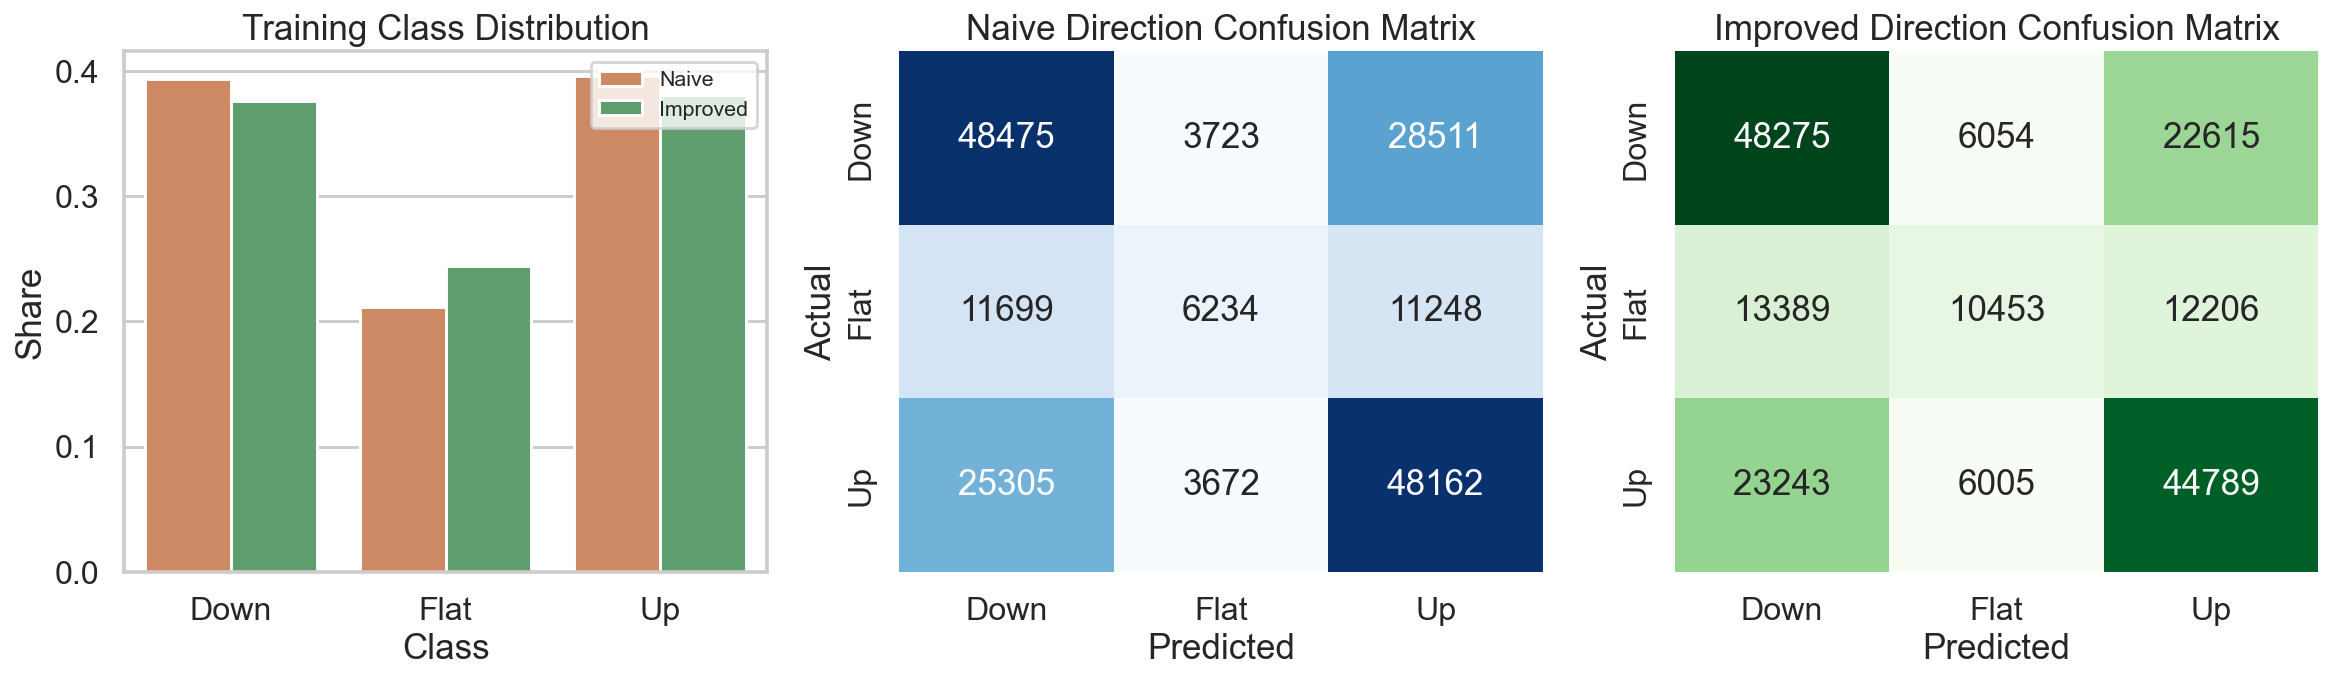

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

train_dist_long = train_class_distribution.melt(id_vars='Class', var_name='Labeling Scheme', value_name='Share')
train_dist_long['Labeling Scheme'] = train_dist_long['Labeling Scheme'].replace({
    'Naive Labels': 'Naive',
    'Improved Labels': 'Improved'
})
sns.barplot(data=train_dist_long, x='Class', y='Share', hue='Labeling Scheme', ax=axes[0], palette=['#dd8452', '#55a868'])
axes[0].set_title('Training Class Distribution')
axes[0].legend(title='', fontsize=11, loc='upper right')

labels = ['Down', 'Flat', 'Up']
sns.heatmap(naive_confusion, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Naive Direction Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(improved_confusion, annot=True, fmt='d', cmap='Greens', cbar=False, xticklabels=labels, yticklabels=labels, ax=axes[2])
axes[2].set_title('Improved Direction Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

fig.tight_layout()
fig.savefig(FIG_DIR / 'classification_diagnostics.png', bbox_inches='tight')
plt.show()


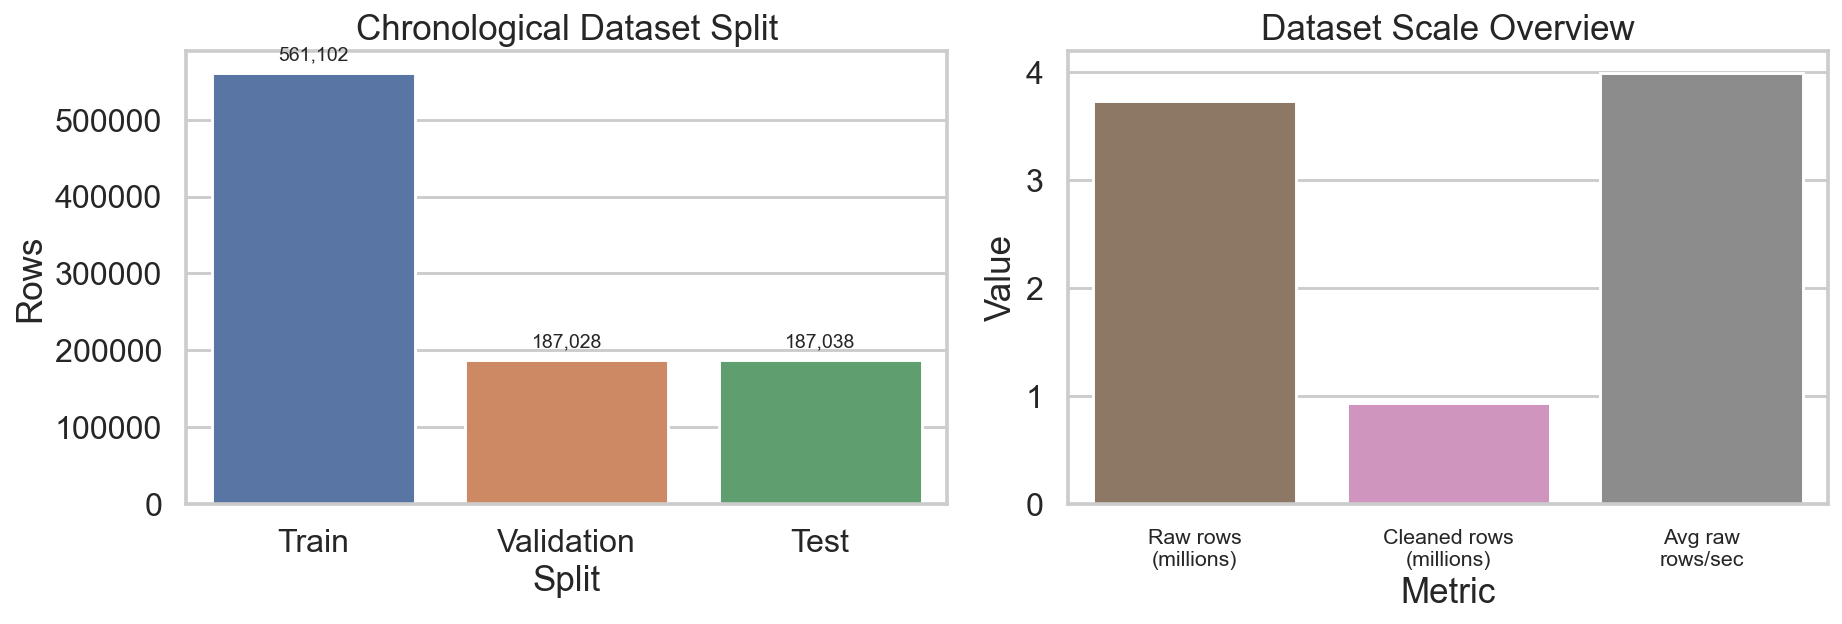

Saved figures to: D:\UMich QUANT\sem4\MATH 629\MATH-629-Project-main\MATH-629-Project-main\report_figures

Suggested report figures:
- classification_diagnostics.png
- dataset_overview.png
- direction_metrics_comparison.png
- regression_results_summary.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

sns.barplot(data=split_df, x='Split', y='Rows', hue='Split', dodge=False, legend=False, ax=axes[0], palette=['#4c72b0', '#dd8452', '#55a868'])
axes[0].set_title('Chronological Dataset Split')
axes[0].set_ylabel('Rows')
for idx, row in split_df.iterrows():
    axes[0].text(idx, row['Rows'] + 12000, f"{row['Rows']:,}", ha='center', va='bottom', fontsize=10)

overview_plot = dataset_overview.copy()
overview_plot['Raw rows'] /= 1_000_000
overview_plot['Cleaned 1s rows'] /= 1_000_000
overview_df = overview_plot.rename_axis('Metric').reset_index(name='Value')
overview_df['Metric'] = ['Raw rows\n(millions)', 'Cleaned rows\n(millions)', 'Avg raw\nrows/sec']
sns.barplot(data=overview_df, x='Metric', y='Value', hue='Metric', dodge=False, legend=False, ax=axes[1], palette=['#937860', '#da8bc3', '#8c8c8c'])
axes[1].set_title('Dataset Scale Overview')
axes[1].set_ylabel('Value')
axes[1].tick_params(axis='x', rotation=0, labelsize=11)

fig.tight_layout()
fig.savefig(FIG_DIR / 'dataset_overview.png', bbox_inches='tight')
plt.show()

print('Saved figures to:', FIG_DIR.resolve())
print('\nSuggested report figures:')
for path in sorted(FIG_DIR.glob('*.png')):
    print('-', path.name)


## Suggested LaTeX Usage

Example:

```latex
\begin{figure}[H]
    \centering
    \includegraphics[width=0.95\textwidth]{report_figures/regression_results_summary.png}
    \caption{Comparison of return forecasting models.}
\end{figure}
```

A good report flow is:
1. `dataset_overview.png` in the data section,
2. `regression_results_summary.png` in the regression results section,
3. `direction_metrics_comparison.png` in the classification results section,
4. `classification_diagnostics.png` in the discussion of label design.